# Advanced radiation and remote sensing

Manfred Brath, Oliver Lemke

## Exercise 4: Atmospheric Brightness Temperature Spectra

# BEM 2025: Adapt for vertical displacements in GOES WV [channels](https://www.weather.gov/media/crp/GOES_16_Guides_FINALBIS.pdf)

Band 8: 5.77-6.6 μm (Central wavelength: 6.19 μm) - Upper-level Tropospheric Water Vapor

Band 9: 6.75-7.15 μm (Central wavelength: 6.95 μm) - Mid-level Tropospheric Water Vapor

Band 10: 7.24-7.44 μm (Central wavelength: 7.34 μm) - Lower-level Tropospheric Water Vapor


In [3]:
# %matplotlib widget

# Set path to line catalogue
import os
# Uncomment and adjust the following lines
# if ARTS_DATA_PATH is not set as environment variable
#    os.environ["ARTS_DATA_PATH"] = "your_path_to/arts-xml-data/:your_path_to/arts-cat-data/:"

import matplotlib.pyplot as plt
import numpy as np
import typhon as ty
from rtcalc import run_arts, tags2tex

plt.style.use(ty.plots.styles("typhon"))

### 1)
The function `run_arts` simulates a brightness temperature and a atmospheric  
zenith opacity spectrum in the microwave spectral range for a midlatitude-summer  
atmosphere over a smooth and wet land surface for a desired height and looking   
direction. Run the function `run_arts` (in rtcalc.py) with the given height and direction.  

In [4]:
# HAD TO ADD THIS CELL to get the spectal data downloaded 
# as per https://github.com/atmtools/arts-lectures/issues/96

import pyarts 
pyarts.cat.download.retrieve(verbose=True)
species = ["N2", "O2", "H2O"]

# Let's confirm the spectrum looks okay

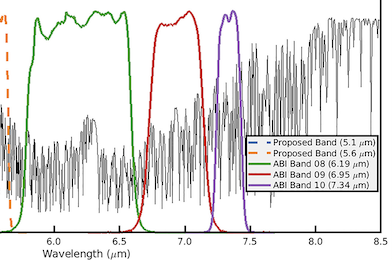

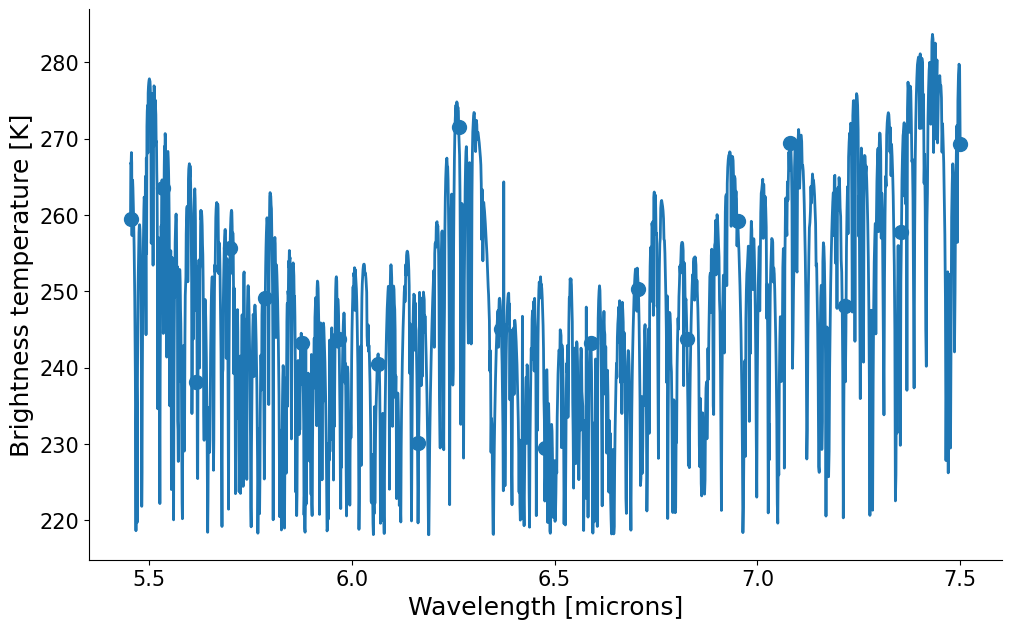

In [41]:
#BEM satellite looking downward at nadir
height = 800000.0
zenith_angle = 180.0

# The whole WVIR range those 3 GOES ABI channels sit in 
freqIR, btIR, od = run_arts(species, zenith_angle, height, fmin=40.0e12, fmax=55e12, fnum=2000)

# coarse spectrum: an average or samples? Looks like samples. Better resolve it well, then average! 
freqIRc, btIRc, od = run_arts(species, zenith_angle, height, fmin=40.0e12, fmax=55e12, fnum=20)

plt.plot(300e6/freqIR *1e6, btIR);
plt.scatter(300e6/freqIRc*1e6, btIRc);   # Unsersample frequencies, do I get an average or aliasing? ANS: Aliasing!

plt.xlabel("Wavelength [microns]")
plt.ylabel("Brightness temperature [K]");

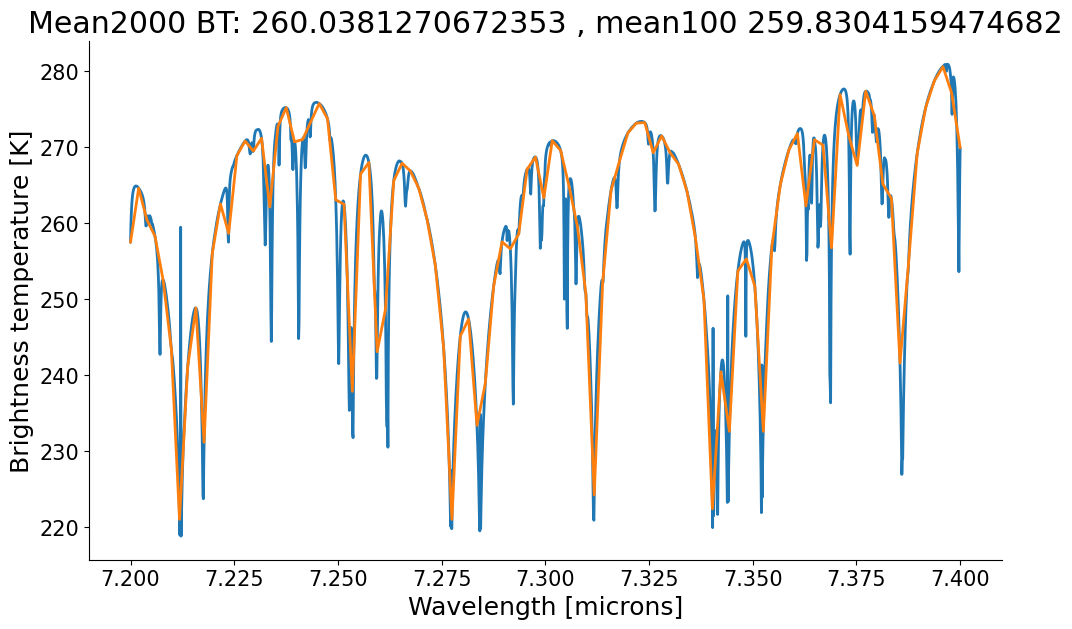

In [25]:
# Zoom in: is 2000 too many for the ABI 7.3 band? Does 100 suffice?
# Answer: let's keep 1000 

# Try 2000 
freq73, bt73, od = run_arts(species, zenith_angle, height, fmin=3e8/ 7.4e-6, fmax=3e8/7.2e-6, fnum=2000)

# coarse spectrum: only 100 frequency samples  
freq73c, bt73c, od = run_arts(species, zenith_angle, height,fmin=3e8/ 7.4e-6, fmax=3e8/7.2e-6, fnum=100)

plt.plot(300e6/freq73 *1e6, bt73);
plt.plot(300e6/freq73c*1e6, bt73c);  # orange

plt.xlabel("Wavelength [microns]")
plt.ylabel("Brightness temperature [K]");
plt.title('Mean2000 BT: '+str(np.mean(bt73))+' , mean100 '+str(np.mean(bt73c))) ;

# ABI bands brightness temperatures

Band 8 ("6.2") 5.75-6.6 microns 

Band 9 ("6.9") 6.7-7.2 microns

Band 10("7.3") 7.2-7.4 microns 

In [13]:
# Convert wavelength ranges to frequency ranges, which must be in increasing order 
# WHOLE REGION: freqIR, btIR, od = run_arts(species, zenith_angle, height, fmin=38.0e12, fmax=55e12)

# The default of 1000 frequencies for each channel is sufficient. 

height = 100000000.0  # TOA
zenith_angle = 180.0

f8, BT8_6_2, od = run_arts(species, zenith_angle, height, fmin=3e8/ 6.6e-6, fmax=3e8/ 5.75e-6)
f9, BT9_6_9, od = run_arts(species, zenith_angle, height, fmin=3e8/ 7.2e-6, fmax=3e8/ 6.7e-6)
f10,BT10_7_3,od = run_arts(species, zenith_angle, height, fmin=3e8/ 7.4e-6, fmax=3e8/ 7.2e-6)

241.6654609921043 248.89332277787327 260.07445143354084


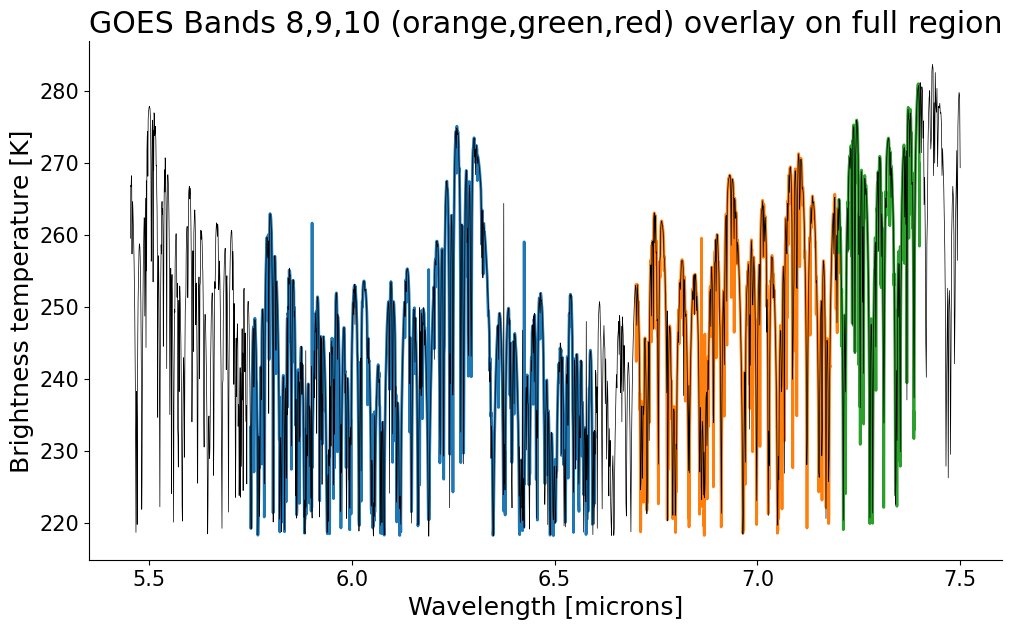

In [59]:
plt.plot(300e6/f8*1e6,  BT8_6_2);
plt.plot(300e6/f9*1e6,  BT9_6_9);
plt.plot(300e6/f10*1e6, BT10_7_3);

# whole range
plt.plot(300e6/freqIR *1e6, btIR, 'black', linewidth=0.5) #, alpha=0.5);

plt.xlabel("Wavelength [microns]")
plt.ylabel("Brightness temperature [K]");
plt.title('GOES Bands 8,9,10 (orange,green,red) overlay on full region')

print(np.mean(BT8_6_2), np.mean(BT9_6_9), np.mean(BT10_7_3))

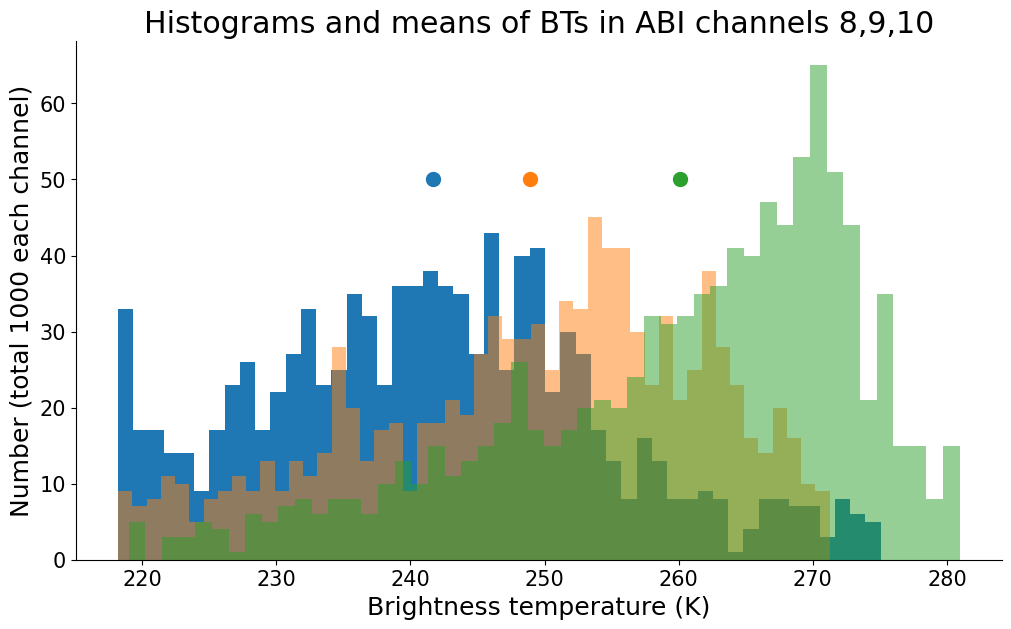

In [44]:
plt.hist(BT8_6_2,50)
plt.scatter([np.mean(BT8_6_2)], [50]);
plt.hist(BT9_6_9,50, alpha=0.5)
plt.scatter([np.mean(BT9_6_9)], [50]);
plt.hist(BT10_7_3,50, alpha=0.5);
plt.scatter([np.mean(BT10_7_3)], [50]);
plt.title('Histograms and means of BTs in ABI channels 8,9,10');
plt.xlabel('Brightness temperature (K)');
plt.ylabel("Number (total 1000 each channel)");